In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_mistralai import ChatMistralAI
from typing import TypedDict
from dotenv import load_dotenv
from rich import print

In [2]:
load_dotenv()

True

In [3]:
llm = ChatMistralAI(model="mistral-small-2506")

In [4]:
# create a state
class BlogState(TypedDict):
  title: str
  outline: str
  content: str
  rating: str

In [5]:
def create_outline(state: BlogState) -> BlogState:
  title = state["title"]

  prompt = f"generate a detailed outline for a blog on the topic: {title}"
  outline = llm.invoke(prompt).content

  state["outline"] = outline

  return state

In [6]:
def create_blog(state: BlogState) -> BlogState:
  # fetch title and outline
  title = state['title'] 
  outline = state['outline']

  prompt = f"write a detailed blog on the title: {title} using the following outline:\n {outline}"

  content = llm.invoke(prompt).content
  
  state['content'] = content

  return state

In [7]:
def evaluate_blog(state: BlogState) -> BlogState:
  # based on outline and blog generated we gotta use LLM to rate the blog
  outline = state['outline']
  content = state['content']

  prompt = f"based on outline:\n{outline}\n\n and blog content:\n{content}\n\n rate my blog and generate an integer score. output should be just an integer"

  rating = llm.invoke(prompt).content

  state['rating'] = rating

  return state

In [8]:
graph = StateGraph(BlogState)

# nodes
graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)
graph.add_node("evaluate_blog", evaluate_blog)

# edges
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", "evaluate_blog")
graph.add_edge("evaluate_blog", END)

workflow = graph.compile()

In [9]:
initial_state = {
  "title": "Rise of AI in India"
}

final_state = workflow.invoke(initial_state)

In [10]:
print(final_state)

{
    'title': 'Rise of AI in India',
    'outline': '# **Blog Outline: The Rise of AI in India**\n\n## **Introduction**\n- Brief overview of AI’s global
impact and its growing significance in India.\n- Why India is emerging as a key player in AI innovation.\n- Purpose
of the blog: Exploring AI’s growth, challenges, and future prospects in India.\n\n---\n\n## **1. The Current State 
of AI in India**\n### **1.1 Government Initiatives & Policies**\n- **National AI Strategy (2018):** India’s AI 
roadmap and key objectives.\n- **AI for All (2020):** Democratizing AI for public good.\n- **Digital India & AI 
Integration:** How AI is enhancing governance and services.\n\n### **1.2 AI Adoption Across Sectors**\n- 
**Healthcare:** AI in diagnostics, telemedicine, and drug discovery.\n- **Finance & Banking:** Fraud detection, 
credit scoring, and fintech innovations.\n- **Agriculture:** Precision farming, crop monitoring, and supply chain 
optimization.\n- **Education:** Personalized learning, AI tutors, and skill development.\n- **Manufacturing & 
Logistics:** Automation, predictive maintenance, and smart factories.\n\n### **1.3 Startup Ecosystem & Private 
Sector Investments**\n- Key AI startups (e.g., Haptik, SigTuple, Uniphore).\n- Investments by tech giants (Google, 
Microsoft, Amazon) in Indian AI research.\n- Role of incubators and accelerators (e.g., iSPIRT, 
NASSCOM).\n\n---\n\n## **2. Key Drivers of AI Growth in India**\n### **2.1 Talent Pool & Academic Research**\n- Top
AI research institutions (IITs, IISc, IIITs).\n- Government scholarships and AI-focused academic programs.\n- Role 
of data science and machine learning bootcamps.\n\n### **2.2 Data Availability & Infrastructure**\n- India’s vast 
data generation (digital payments, social media, IoT).\n- National Data Sharing Framework & Responsible AI 
principles.\n- Cloud computing and AI infrastructure (AWS, Google Cloud, Azure).\n\n### **2.3 Market Demand & 
Economic Potential**\n- AI’s role in job creation vs. job displacement.\n- AI in BPOs, customer service, and 
automation.\n- India’s AI market size projections (2023-2030).\n\n---\n\n## **3. Challenges Facing AI in 
India**\n### **3.1 Ethical & Regulatory Concerns**\n- Data privacy laws (Personal Data Protection Bill).\n- Bias in
AI algorithms and fairness issues.\n- Lack of standardized AI governance frameworks.\n\n### **3.2 Infrastructure & 
Skill Gaps**\n- Limited access to high-performance computing (HPC) resources.\n- Need for upskilling the workforce 
in AI/ML.\n- Regional disparities in AI adoption.\n\n### **3.3 Economic & Social Barriers**\n- High cost of AI 
implementation for SMEs.\n- Digital divide and AI accessibility in rural areas.\n- Ethical concerns around 
AI-driven surveillance.\n\n---\n\n## **4. Future Prospects & Opportunities**\n### **4.1 Emerging AI Trends in 
India**\n- Generative AI (Chatbots, content creation).\n- AI in cybersecurity and fraud prevention.\n- AI-powered 
smart cities and urban planning.\n\n### **4.2 India’s Global AI Ambitions**\n- Collaboration with international AI 
hubs (US, EU, China).\n- India’s role in global AI ethics and policy-making.\n- Potential for AI-driven exports (AI
solutions for developing nations).\n\n### **4.3 Policy Recommendations for Sustainable AI Growth**\n- Strengthening
AI education and research funding.\n- Encouraging public-private partnerships.\n- Building a robust AI ethics and 
compliance framework.\n\n---\n\n## **Conclusion**\n- Recap of India’s AI journey and its transformative 
potential.\n- Call to action: How individuals, businesses, and policymakers can contribute.\n- Final thoughts on 
India’s position as a future AI leader.\n\n---\n\n## **Additional Sections (Optional)**\n- **Case Studies:** 
Success stories of AI implementation in Indian industries.\n- **Interviews/Expert Opinions:** Insights from AI 
leaders in India.\n- **Infographics/Charts:** Visual representation of AI growth statistics.\n\nThis outline 
ensures a structured, engagin

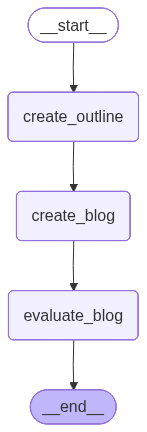

In [11]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())